Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)
Creen un Jupyter Notebook nuevo, carguen el dataset proporcionado en GitHub y seleccionen a su "Jugador Estrella" (puede ser el jugador con más goles o su favorito del dataset, la decisión es suya).

In [22]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

import matplotlib.pyplot as plt

In [23]:
# Instrucción: Carga tu archivo limpio de la semana 4 ('playstore_limpio.csv').
# Si por alguna razón no lo tienes, usa el siguiente bloque para descargar y pre-limpiar lo básico:

url = "https://raw.githubusercontent.com/mricardo89/data-mining/refs/heads/main/Unit-III/datasets/players_data-2025_2026.csv"
df = pd.read_csv(url)

print("Dimensiones del dataset: ", df.shape)
df.head()

Dimensiones del dataset:  (2839, 102)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,3,0,0,20,51,5,37,17,27,0
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,0,0,3,1,0,3,2,4,0
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,7,3,2,30,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,1,0,0,3,0,0,1,2,1,0


In [24]:
caracteristicas = ["Gls", "Ast", "Min", "Sh"]
nombre_jugador = "Erling Haaland"

X = df[caracteristicas].copy()

print("Caracteristicas seleccionadas: ", caracteristicas)

print("\nMatriz X: ", X.head())

print("\nJugador estrella: ", nombre_jugador)
jugador_estrella = df[df["Player"] == nombre_jugador].iloc[0]
print("\nEstadisticas de Erling Haaland: ")
print(jugador_estrella[caracteristicas])

Caracteristicas seleccionadas:  ['Gls', 'Ast', 'Min', 'Sh']

Matriz X:     Gls  Ast   Min  Sh
0    4    5  2449  47
1    0    0    17   0
2    0    0   164   0
3    2    0   681  17
4    0    0   138   4

Jugador estrella:  Erling Haaland

Estadisticas de Erling Haaland: 
Gls      27
Ast       8
Min    2953
Sh      126
Name: 1104, dtype: object


In [25]:
indice_estrella = jugador_estrella.name

vector_estrella = X.loc[indice_estrella].values

print("Vector del Jugador Estrella:")
print(caracteristicas)
print(vector_estrella)

X_candidatos = X.drop(index=indice_estrella)

print("Jugadores candidatos:", len(X_candidatos))

Vector del Jugador Estrella:
['Gls', 'Ast', 'Min', 'Sh']
[  27    8 2953  126]
Jugadores candidatos: 2838


Pregunta de control: Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)?

Aplicar la operacion de Z-Score para estandarizar las caracteristicas numericas antes de calcular las distancias, para evitar que una variable como "Minutos Jugados (Min)" tenga una influencia mayor que las demás variables como "Gls (Goles)".

In [26]:
scaler = StandardScaler()

X_estandarizada = scaler.fit_transform(X)

X_estandarizada = pd.DataFrame(
    X_estandarizada,
    columns=caracteristicas,
    index=df.index
)

print(X_estandarizada.head())

        Gls       Ast       Min        Sh
0  0.797892  2.095652  1.277629  1.671185
1 -0.566285 -0.632501 -1.247683 -0.823264
2 -0.566285 -0.632501 -1.095043 -0.823264
3  0.115804 -0.632501 -0.558206  0.078984
4 -0.566285 -0.632501 -1.122040 -0.610970


Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)
La distancia euclidiana (la línea recta) no es la única forma de viajar por el espacio vectorial. Existen otras métricas como la Distancia Manhattan (Norma L1), que calcula la distancia moviéndose estrictamente en ángulos rectos, como si un taxi navegara por las cuadras de Nueva York, también es conocida como la distancia del taxista.

In [27]:
## Reemplazo con distancia euclidiana

vector_estrella_std = X_estandarizada.loc[indice_estrella].values

distancias_euclidianas = pairwise_distances(
    X_estandarizada.drop(index=indice_estrella),
    [vector_estrella_std],
    metric="euclidean"
).flatten()

candidatos_euclidiana = df.drop(index=indice_estrella).copy()

candidatos_euclidiana["Distancia"] = distancias_euclidianas

reemplazo_euclidiano = candidatos_euclidiana.sort_values(
    "Distancia"
).iloc[0]

print("Jugador Estrella:", jugador_estrella["Player"])
print("Reemplazo sugerido:", reemplazo_euclidiano["Player"])
print("Distancia:", reemplazo_euclidiano["Distancia"])

Jugador Estrella: Erling Haaland
Reemplazo sugerido: Kylian Mbappé
Distancia: 2.099164035808964


In [28]:
## Codigo custom para la distancia manhattan

def distancia_manhattan(vector_a, vector_b):
    return np.sum(np.abs(vector_a - vector_b))

In [29]:
## Reemplazo con distancia manhattan

distancias_manhattan = []

for indice, jugador in X_estandarizada.drop(index=indice_estrella).iterrows():
    distancia = distancia_manhattan(
        vector_estrella_std,
        jugador.values
    )
    
    distancias_manhattan.append((indice, distancia))

resultado_manhattan = pd.DataFrame(
    distancias_manhattan,
    columns=["Indice", "Distancia"]
)

resultado_manhattan = resultado_manhattan.sort_values("Distancia")

indice_manhattan = resultado_manhattan.iloc[0]["Indice"]

reemplazo_manhattan = df.loc[indice_manhattan]

print("Jugador Estrella:", jugador_estrella["Player"])
print("Reemplazo sugerido:", reemplazo_manhattan["Player"])
print("Distancia:", resultado_manhattan.iloc[0]["Distancia"])

Jugador Estrella: Erling Haaland
Reemplazo sugerido: Kylian Mbappé
Distancia: 3.7480301625671957


Analisis critico

Las dos métricas buscan encontrar jugadores cuyos vectores sean similares al vector del jugador estrella, pero calculan la diferencia de manera distinta.

La distancia euclidiana utiliza las diferencias al cuadrado y posteriormente calcula una raíz cuadrada. Por esta razón, las diferencias grandes entre dos jugadores tienen una mayor influencia en el resultado.

En cambio, la distancia Manhattan suma las diferencias absolutas de cada característica. Esto hace que cada dimensión contribuya de manera más directa a la distancia total.


Fase 3: El Reto de Visualización en 4D (Investigación Independiente)
El director técnico quiere ver un reporte visual de por qué el jugador que sugirieron es el más parecido al original.

El problema físico es que ustedes seleccionaron 4 (o más) características. Los seres humanos solo podemos ver un eje X, un eje Y y un eje Z.

In [30]:
# Tercer jugador aleatorio
tercer_jugador = df.sample(1, random_state=42).iloc[0]

print("Jugador Estrella:", jugador_estrella["Player"])
print("Reemplazo:", reemplazo_euclidiano["Player"])
print("Tercer jugador:", tercer_jugador["Player"])

Jugador Estrella: Erling Haaland
Reemplazo: Kylian Mbappé
Tercer jugador: Sam Byram


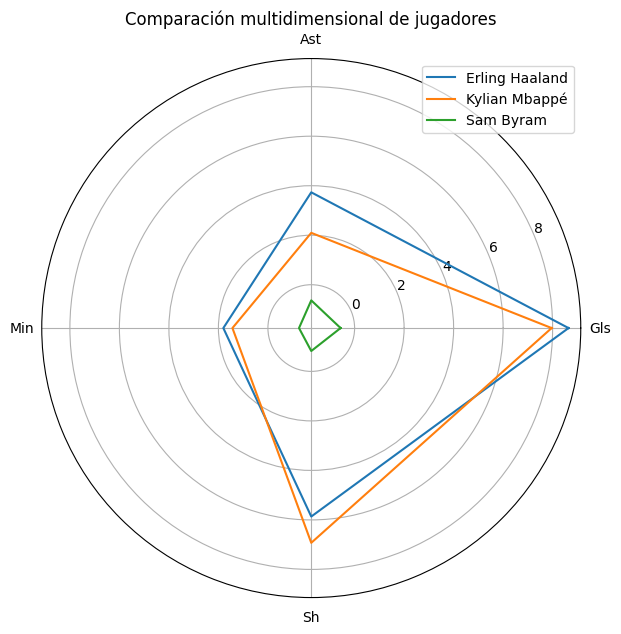

In [31]:
# jugadores que vamos a comparar
jugadores = [
    jugador_estrella.name,
    reemplazo_euclidiano.name,
    tercer_jugador.name
]

# obtener sus datos estandarizados
datos = X_estandarizada.loc[jugadores]

# crear los ángulos
angulos = np.linspace(0, 2*np.pi, len(caracteristicas), endpoint=False)
angulos = np.append(angulos, angulos[0])

# crear gráfico
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})

# dibujar cada jugador
for i in range(3):
    valores = np.append(datos.iloc[i].values, datos.iloc[i].values[0])
    ax.plot(angulos, valores, label=df.loc[jugadores[i], "Player"])

# nombres de las características
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(caracteristicas)

ax.set_title("Comparación multidimensional de jugadores")
ax.legend()

plt.show()